In [177]:
# Installation nécessaire 
!pip install great_tables
!pip install cartiflette
!pip install pandas geopandas matplotlib

In [178]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import importlib
import utils
importlib.reload(utils)

from utils import normaliser_code_dep, chercher_candidat

In [179]:
import pandas as pd
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_4665/572529936.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


# 1. Explorations générales

### Exploration initiale des données 

In [180]:
# Taille du dataframe
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# Noms des colonnes
print(f"\nLes colonnes de la table : {df.columns.tolist()}")

# Types des colonnes
print("\nTypes des colonnes :")
print(df.dtypes)

# Aperçu des premières lignes
df.head()

Dimensions : 528675 lignes × 7 colonnes

Les colonnes de la table : ['code_departement', 'libelle_departement', 'code_commune', 'libelle_commune', 'prenom', 'nom', 'voix']

Types des colonnes :
code_departement       object
libelle_departement    object
code_commune            int64
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [181]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
code_departement            0
libelle_departement         0
code_commune                0
libelle_commune             0
prenom                 105735
nom                         0
voix                        0
dtype: int64


Les valeurs manquantes dans les colonnes `prenom` s'expliquent 
par les lignes correspondant aux votes non exprimés (abstentions, blancs, nuls) 
qui n'ont pas de candidat associé, donc pas de prénom ni de nom.

In [182]:
# Statistiques descriptives sur les voix
print("Statistiques sur la colonne 'voix' :")
print(df["voix"].describe())

Statistiques sur la colonne 'voix' :
count    528675.000000
mean         92.207644
std        1075.348381
min           0.000000
25%           3.000000
50%          11.000000
75%          42.000000
max      372820.000000
Name: voix, dtype: float64


In [183]:
# Valeurs uniques des colonnes catégorielles
print(f"Nombre de départements : {df['code_departement'].nunique()}")
print(f"Nombre de communes     : {df['code_commune'].nunique()}")


Nombre de départements : 108
Nombre de communes     : 908


In [184]:
# Vérification des doublons
print(f"Nombre de doublons : {df.duplicated().sum()}")

Nombre de doublons : 0


In [185]:
# Question 1

df['code_commune'] = (
    df['code_departement'].astype(str) +
    df['code_commune'].astype(str).str.zfill(3)
    )

df['candidat'] = ( df['prenom'] +' '+ df['nom'])

df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


In [186]:
# Question 2
df['candidat'].value_counts()

candidats = df['candidat'].nunique()

print( f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


In [187]:
# Question 3

results = df[~df["candidat"].isna()].groupby("candidat")["voix"].sum().reset_index()
results = df.groupby("candidat")["voix"].sum().reset_index()
total_voix = results["voix"].sum()
results["score (%)"] = (results["voix"] / total_voix) * 100
results = results.sort_values(by="voix", ascending=False)

results


,candidat,voix,score (%)
1,Emmanuel MACRON,9783058,27.845822
5,Marine LE PEN,8133828,23.151568
4,Jean-Luc MÉLENCHON,7712520,21.952386
11,Éric ZEMMOUR,2485226,7.073776
9,Valérie PÉCRESSE,1679001,4.778993
10,Yannick JADOT,1627853,4.633409
3,Jean LASSALLE,1101387,3.134912
2,Fabien ROUSSEL,802422,2.283959
7,Nicolas DUPONT-AIGNAN,725176,2.064091
0,Anne HIDALGO,616478,1.754701


In [188]:
# Question 3
from great_tables import GT

result2 = (
    df.groupby("candidat", as_index=False)["voix"]
    .sum()
    .sort_values(by="voix", ascending=False)
)

total_voix = result2["voix"].sum()
result2["score (%)"] = (result2["voix"] / total_voix) * 100

# 2. Création du tableau GT
table = (
    GT(result2)
    .tab_header(
        title="Résultats du premier tour",
    )
    .cols_label(
        candidat="Candidat",
        voix="Nombre votes (total)",
        **{"score (%)": "Score (% votes exprimés)"}
    )
    .fmt_number(
        columns="voix",
        decimals=0,
        use_seps=True
    )
    .fmt_number(
        columns="score (%)",
        decimals=2
    )
)

table


GT(_tbl_data=                 candidat     voix  score (%)
1         Emmanuel MACRON  9783058  27.845822
5           Marine LE PEN  8133828  23.151568
4      Jean-Luc MÉLENCHON  7712520  21.952386
11           Éric ZEMMOUR  2485226   7.073776
9        Valérie PÉCRESSE  1679001   4.778993
10          Yannick JADOT  1627853   4.633409
3           Jean LASSALLE  1101387   3.134912
2          Fabien ROUSSEL   802422   2.283959
7   Nicolas DUPONT-AIGNAN   725176   2.064091
0            Anne HIDALGO   616478   1.754701
8         Philippe POUTOU   268904   0.765390
6        Nathalie ARTHAUD   197094   0.560995, _body=<great_tables._gt_data.Body object at 0x7fe55c344230>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score (%)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fe59b0e0bb0>, _spanners=Spanners([]), _heading=Heading(title='Résultats du premier tour', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fe59f57ad50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fe59f57b410>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fe59b0e3000>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fe59f579430>, <great_tables._gt_data.FormatInfo object at 0x7fe59f578fb0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(sc

# 2. Comparaison des scores départements aux moyennes nationales.

In [189]:
# Question 4
# On retire les abstentions, blancs et nuls
df_votes = df[~df["candidat"].isna()].copy()

# Total des voix par département et par candidat
score_departements = (
    df_votes
    .groupby(["code_departement", "candidat"], as_index=False)["voix"]
    .sum()
    .rename(columns={"voix": "votes"})
)

# Total des votes exprimés par département
totaux_departement = (
    score_departements
    .groupby("code_departement", as_index=False)["votes"]
    .sum()
    .rename(columns={"votes": "total_votes_departement"})
)

# Ajout du total départemental et calcul du score en pourcentage
score_departements = score_departements.merge(totaux_departement, on="code_departement")
score_departements["score"] = (
    score_departements["votes"] / score_departements["total_votes_departement"] * 100
).round(2)

# Tri final
score_departements = ( 
    score_departements
    .drop(columns=["total_votes_departement"])
    .sort_values(by=["code_departement", "votes"],ascending=[True, False])
    .reset_index(drop=True)
)

# Affichage du résultat
score_departements.head(10)


,code_departement,candidat,votes,score
0,01,Emmanuel MACRON,92206,27.69
1,01,Marine LE PEN,86755,26.05
2,01,Jean-Luc MÉLENCHON,57832,17.37
3,01,Éric ZEMMOUR,27530,8.27
4,01,Valérie PÉCRESSE,17572,5.28
5,01,Yannick JADOT,15843,4.76
6,01,Jean LASSALLE,10876,3.27
7,01,Nicolas DUPONT-AIGNAN,8998,2.70
8,01,Fabien ROUSSEL,5938,1.78
9,01,Anne HIDALGO,5644,1.69


In [190]:
# cellule de test 
score_departements[score_departements['code_departement'] == '11']

,code_departement,candidat,votes,score
120,11,Marine LE PEN,64027,30.14
121,11,Emmanuel MACRON,43104,20.29
122,11,Jean-Luc MÉLENCHON,42039,19.79
123,11,Éric ZEMMOUR,18434,8.68
124,11,Jean LASSALLE,12382,5.83
125,11,Valérie PÉCRESSE,7350,3.46
126,11,Yannick JADOT,6322,2.98
127,11,Anne HIDALGO,6166,2.90
128,11,Fabien ROUSSEL,5622,2.65
129,11,Nicolas DUPONT-AIGNAN,4206,1.98


In [191]:
# Affichage avec great_tables
from great_tables import GT

dept_11 = score_departements[score_departements['code_departement'] == '11']

(
    GT(dept_11)
    .tab_header(
        title="Scores dans l'Aude (11)",
    )
    .cols_label(
        code_departement="code_departement",
        candidat="candidat",
        votes="votes",
        score="score"
    )
    .fmt_number(columns="votes", sep_mark="", dec_mark=",", decimals=0)
    .fmt_number(columns="score", decimals=2, pattern="{x}%")
)

GT(_tbl_data=    code_departement               candidat  votes  score
120               11          Marine LE PEN  64027  30.14
121               11        Emmanuel MACRON  43104  20.29
122               11     Jean-Luc MÉLENCHON  42039  19.79
123               11           Éric ZEMMOUR  18434   8.68
124               11          Jean LASSALLE  12382   5.83
125               11       Valérie PÉCRESSE   7350   3.46
126               11          Yannick JADOT   6322   2.98
127               11           Anne HIDALGO   6166   2.90
128               11         Fabien ROUSSEL   5622   2.65
129               11  Nicolas DUPONT-AIGNAN   4206   1.98
130               11        Philippe POUTOU   1748   0.82
131               11       Nathalie ARTHAUD   1026   0.48, _body=<great_tables._gt_data.Body object at 0x7fe55a8cfa70>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='code_departement', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='left', column_width=None), ColInfo(var='votes', type=<ColInfoTypeEnum.default: 1>, column_label='votes', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fe59b11f620>, _spanners=Spanners([]), _heading=Heading(title="Scores dans l'Aude (11)", subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fe59f57a150>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fe59f57a390>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fe59b11ecf0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fe59f57a450>, <great_tables._gt_data.FormatInfo object at 0x7fe59f57a570>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='val

In [192]:
# Question 5
# On réutilise directement le score calculé de la Q3
score_national = (
    results
    .rename(columns={
        "voix": "votes_national",
        "score (%)": "score_national"
    })
)
score_national["score_national"] = score_national["score_national"].round(2)
score_national["votes_national"] = score_national["votes_national"].round(2)

# Fusion avec les scores départementaux
score_departements = (
    score_departements
    [["code_departement", "candidat", "votes", "score"]] 
    .merge(score_national, on="candidat")
)

# Test sur le département 11
score_departements[score_departements['code_departement'] == '11']



,code_departement,candidat,votes,score,votes_national,score_national
120,11,Marine LE PEN,64027,30.14,8133828,23.15
121,11,Emmanuel MACRON,43104,20.29,9783058,27.85
122,11,Jean-Luc MÉLENCHON,42039,19.79,7712520,21.95
123,11,Éric ZEMMOUR,18434,8.68,2485226,7.07
124,11,Jean LASSALLE,12382,5.83,1101387,3.13
125,11,Valérie PÉCRESSE,7350,3.46,1679001,4.78
126,11,Yannick JADOT,6322,2.98,1627853,4.63
127,11,Anne HIDALGO,6166,2.90,616478,1.75
128,11,Fabien ROUSSEL,5622,2.65,802422,2.28
129,11,Nicolas DUPONT-AIGNAN,4206,1.98,725176,2.06


In [193]:
from great_tables import GT

dept_11 = score_departements[score_departements['code_departement'] == '11']

(
    GT(dept_11)
    .tab_header(
        title="Scores dans l'Aude (11)",
        subtitle="Comparaison département vs national"
    )
    .cols_label(
        code_departement="code_departement",
        candidat="candidat",
        votes="votes_departement",
        score="score_departement",
        votes_national="votes_national",
        score_national="score_national"
    )
    .fmt_number(columns="votes", sep_mark="", dec_mark=",", decimals=0)
    .fmt_number(columns="votes_national", sep_mark="", dec_mark=",", decimals=0)
    .fmt_number(columns="score", decimals=2, pattern="{x}%")
    .fmt_number(columns="score_national", decimals=2, pattern="{x}%")
)

GT(_tbl_data=    code_departement               candidat  votes  score  votes_national  \
120               11          Marine LE PEN  64027  30.14         8133828   
121               11        Emmanuel MACRON  43104  20.29         9783058   
122               11     Jean-Luc MÉLENCHON  42039  19.79         7712520   
123               11           Éric ZEMMOUR  18434   8.68         2485226   
124               11          Jean LASSALLE  12382   5.83         1101387   
125               11       Valérie PÉCRESSE   7350   3.46         1679001   
126               11          Yannick JADOT   6322   2.98         1627853   
127               11           Anne HIDALGO   6166   2.90          616478   
128               11         Fabien ROUSSEL   5622   2.65          802422   
129               11  Nicolas DUPONT-AIGNAN   4206   1.98          725176   
130               11        Philippe POUTOU   1748   0.82          268904   
131               11       Nathalie ARTHAUD   1026   0.48          197094   

     score_national  
120           23.15  
121           27.85  
122           21.95  
123            7.07  
124            3.13  
125            4.78  
126            4.63  
127            1.75  
128            2.28  
129            2.06  
130            0.77  
131            0.56  , _body=<great_tables._gt_data.Body object at 0x7fe55a389040>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='code_departement', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='left', column_width=None), ColInfo(var='votes', type=<ColInfoTypeEnum.default: 1>, column_label='votes_departement', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='score_departement', column_align='right', column_width=None), ColInfo(var='votes_national', type=<ColInfoTypeEnum.default: 1>, column_label='votes_national', column_align='right', column_width=None), ColInfo(var='score_national', type=<ColInfoTypeEnum.default: 1>, column_label='score_national', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fe58e3afad0>, _spanners=Spanners([]), _heading=Heading(title="Scores dans l'Aude (11)", subtitle='Comparaison département vs national', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fe59b52c890>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fe59b52d2b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fe59b52e1b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fe59b52cc50>, <great_tables._gt_data.FormatInfo object at 0x7fe59b52d5b0>, <great_tables._gt_data.FormatInfo object at 0x7fe59b52c470>, <great_tables._gt_data.FormatInfo object at 0x7fe59b52d970>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_w

In [194]:
# Question 6
score_departements["surrepresentation"] = (
    (score_departements["score"] - score_departements["score_national"])
    / score_departements["score_national"]
    * 100
).round(2)

# Vérification sur l'Aude (11)
score_departements[score_departements['code_departement'] == '11'].head(5)

,code_departement,candidat,votes,score,votes_national,score_national,surrepresentation
120,11,Marine LE PEN,64027,30.14,8133828,23.15,30.19
121,11,Emmanuel MACRON,43104,20.29,9783058,27.85,-27.15
122,11,Jean-Luc MÉLENCHON,42039,19.79,7712520,21.95,-9.84
123,11,Éric ZEMMOUR,18434,8.68,2485226,7.07,22.77
124,11,Jean LASSALLE,12382,5.83,1101387,3.13,86.26


Candidat trouvé : Éric ZEMMOUR


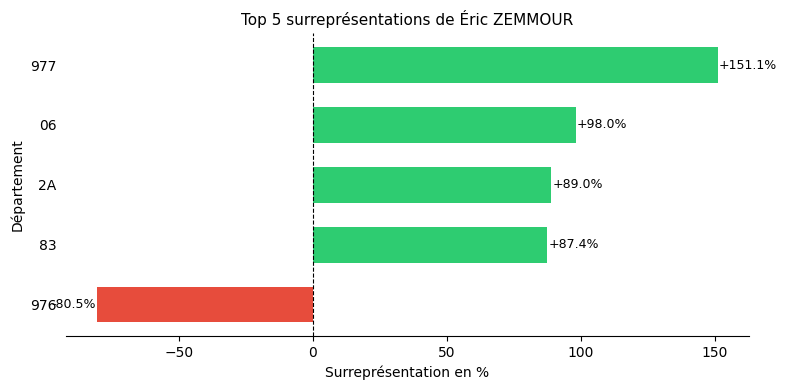

Candidat trouvé : Jean-Luc MÉLENCHON


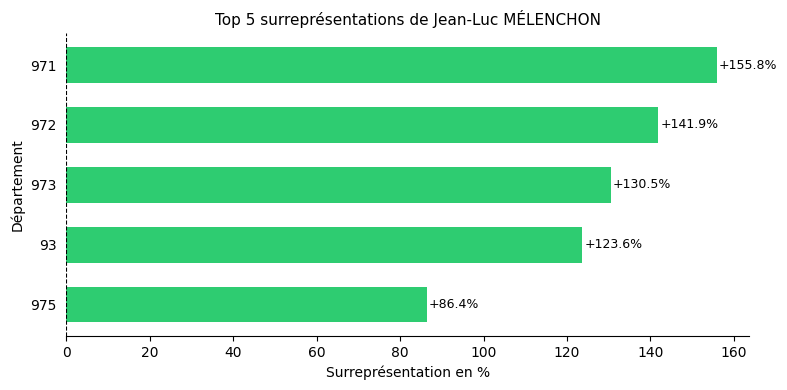

Candidat trouvé : Marine LE PEN


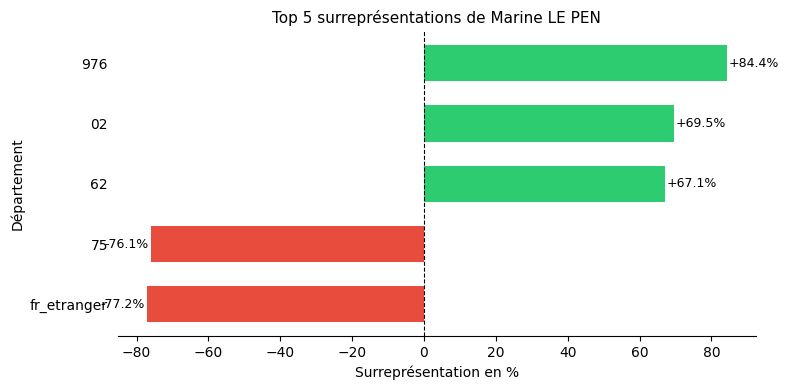

In [195]:
import matplotlib.pyplot as plt

def plot_surrepresentation(nom, score_departements, top_n=5):
    """
    Affiche un graphique en barres horizontales des départements
    où un candidat est le plus sur/sous-représenté.
    
    Parameters
    ----------
    nom : str
        Nom ou partie du nom du candidat (ex: "ZEMMOUR", "Marine")
    score_departements : pd.DataFrame
        DataFrame contenant la colonne 'surrepresentation'
    top_n : int
        Nombre de départements à afficher (défaut: 5)
    """

    # On effectue un traitement pour vérifier que la chaîne entrée correspond bien à un candidat 
    candidat_nom = chercher_candidat(nom, score_departements)
    print(f"Candidat trouvé : {candidat_nom}")
    
    # Filtrer pour le candidat
    df_candidat = (
        score_departements[score_departements["candidat"] == candidat_nom]
        .copy()
        .assign(abs_surr=lambda x: x["surrepresentation"].abs())
        .sort_values("abs_surr", ascending=False)
        .head(top_n)
        .sort_values("surrepresentation")
    )
    
    # Couleurs
    colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in df_candidat["surrepresentation"]]
    
    # Figure minimaliste
    fig, ax = plt.subplots(figsize=(8, 4))
    
    bars = ax.barh(
        df_candidat["code_departement"],
        df_candidat["surrepresentation"],
        color=colors,
        height=0.6
    )
    
    ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
    
    for bar, val in zip(bars, df_candidat["surrepresentation"]):
        ax.text(
            bar.get_width() + (0.5 if val >= 0 else -0.5),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9
        )
    
    ax.set_title(f"Top {top_n} surreprésentations de {candidat_nom}", fontsize=11)
    ax.set_xlabel("Surreprésentation en %")
    ax.set_ylabel("Département")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)
    
    plt.tight_layout()
    plt.show()


# Exemple d'utilisation
plot_surrepresentation("ZEMMOUR", score_departements, 5)
plot_surrepresentation("MÉLENCHON", score_departements)
plot_surrepresentation("Le pen", score_departements)

# 3. Un peu de cartographie

In [196]:
from cartiflette import carti_download
departement_borders = carti_download(
values = ["France"],
crs = 4326,
borders = "DEPARTEMENT",
vectorfile_format="geojson",
simplification=50,
filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
source="EXPRESS-COG-CARTO-TERRITOIRE",
year=2022)

In [197]:
def cartographier_candidat(score_departements, departement_borders, nom_candidat):

    # Copie des données
    df_score = score_departements.copy()
    df_carte = departement_borders.copy()

    # Recherche flexible du candidat en normalisant le texte 
    nom_exact = chercher_candidat(nom_candidat, score_departements)
    print(f"Candidat trouvé : {nom_exact}")

    candidat_filtre = df_score[df_score["candidat"] == nom_exact].copy()

    # Normalisation des codes département
    candidat_filtre["code_departement"] = normaliser_code_dep(candidat_filtre["code_departement"])

    # Détection automatique de la colonne code du fond de carte
    meilleure_colonne = None
    meilleur_nb_matchs = -1

    for col in df_carte.columns:
        if col == "geometry":
            continue

        try:
            valeurs_carte = normaliser_code_dep(df_carte[col])
            nb_matchs = valeurs_carte.isin(candidat_filtre["code_departement"]).sum()

            if nb_matchs > meilleur_nb_matchs:
                meilleur_nb_matchs = nb_matchs
                meilleure_colonne = col
        except Exception:
            pass

    # Si aucune colonne ne marche, on essaie l'index
    if meilleur_nb_matchs == 0:
        valeurs_index = normaliser_code_dep(pd.Series(df_carte.index, index=df_carte.index))
        nb_matchs_index = valeurs_index.isin(candidat_filtre["code_departement"]).sum()

        if nb_matchs_index > meilleur_nb_matchs:
            df_carte = df_carte.reset_index().rename(columns={"index": "code_dep_index"})
            meilleure_colonne = "code_dep_index"
            meilleur_nb_matchs = nb_matchs_index

    if meilleure_colonne is None or meilleur_nb_matchs == 0:
        raise ValueError("Aucune colonne compatible trouvée pour les codes département")

    df_carte["code_departement"] = normaliser_code_dep(df_carte[meilleure_colonne])

    # Jointure
    carte_finale = df_carte.merge(
        candidat_filtre[["code_departement", "candidat", "votes", "score"]],
        on="code_departement",
        how="left"
    )

    # Carte
    fig, ax = plt.subplots(figsize=(11, 11))
    carte_finale.plot(
        column="score",
        cmap="RdBu_r",
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Pas de données"}
    )

    ax.set_title(f"Score de {nom_candidat} par département")
    ax.axis("off")
    plt.show()

    return carte_finale



Candidat trouvé : Marine LE PEN


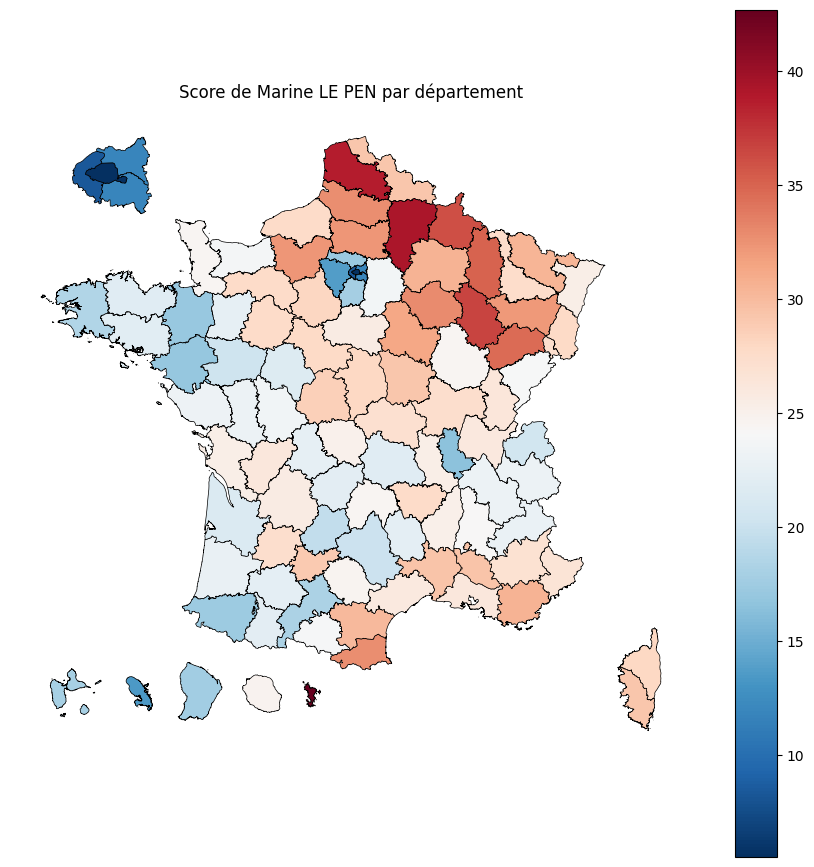

Candidat trouvé : Emmanuel MACRON


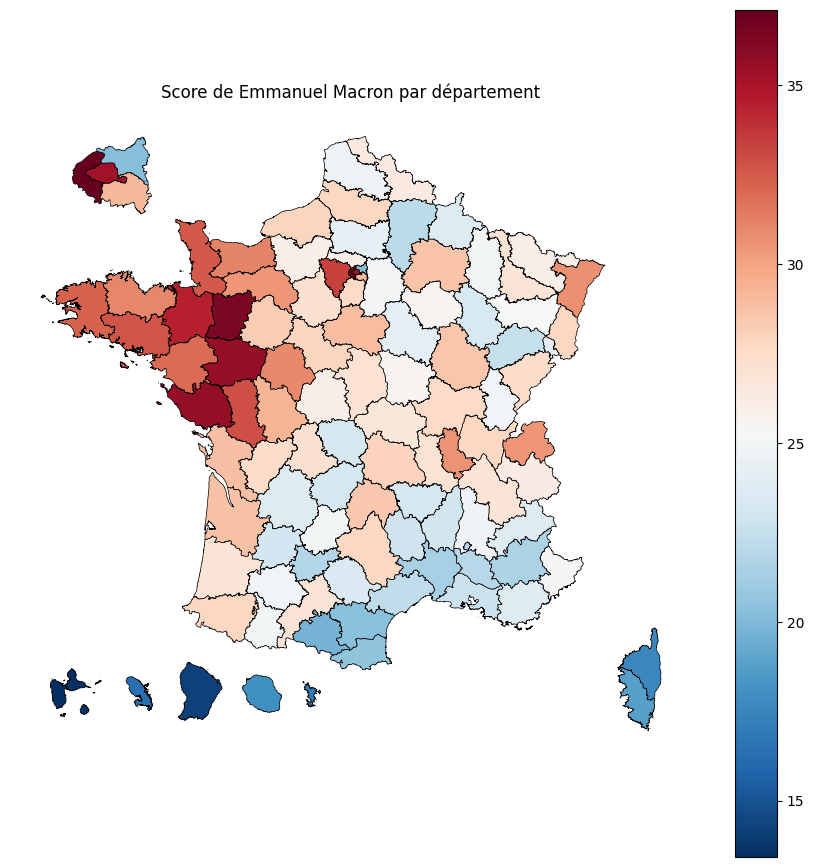

Candidat trouvé : Éric ZEMMOUR


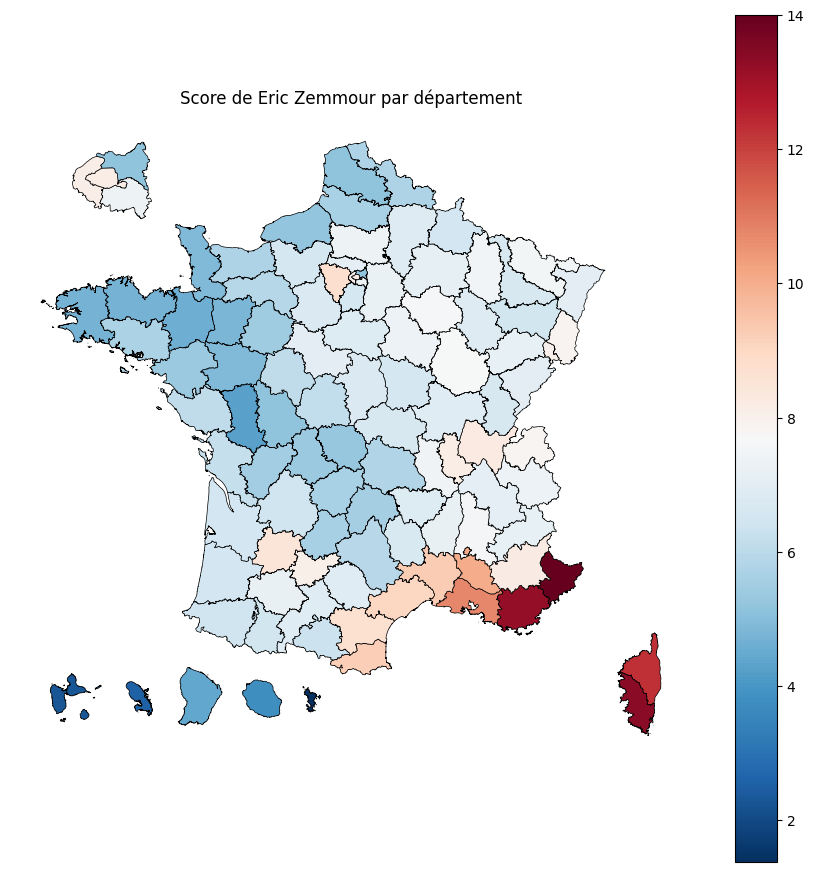

In [198]:
carte_marine = cartographier_candidat(score_departements, departement_borders, "Marine LE PEN")
carte_marine = cartographier_candidat(score_departements, departement_borders, "Emmanuel Macron")
carte_marine = cartographier_candidat(score_departements, departement_borders, "Eric Zemmour")